# BipedalWalker Backflip Agent
### Teaching a 2D Bipedal Robot to Perform a Full Rotation using Curriculum Reinforcement Learning

This project extends the standard `BipedalWalker-v3` gymnasium environment to train a reinforcement learning agent capable of performing a **complete aerial flip**, rather than simply walking forward.

The task is significantly harder than the original walking objective: the agent must learn to jump, rotate its body through 360°, and land stably — a sequence that requires coordinated exploration across multiple phases. To address this challenge, we design a **three-stage curriculum** that progressively introduces rotation, landing, and balance as sub-goals.

## 1. Environment & Custom Modifications

### 1.1 Original Environment: `BipedalWalker-v3`

`BipedalWalker-v3` is a 2D physics simulation from Gymnasium's Box2D suite. A bipedal robot must walk across procedurally generated terrain to reach the right end of the map. The normal variant features slightly uneven ground; the `hardcore=True` variant adds ladders, stumps, and pitfalls.

#### Action Space
Continuous `Box(-1.0, 1.0, (4,), float32)`. Each value applies torque to one of four joints:

| Index | Joint |
|---|---|
| 0 | Hip 1 |
| 1 | Knee 1 |
| 2 | Hip 2 |
| 3 | Knee 2 |

#### Observation Space (24-dimensional)
The standard observation vector encodes hull kinematics, joint states, ground contact flags, and 10 lidar range-finder measurements:

| Indices | Description |
|---|---|
| 0 | Hull angle (rad) |
| 1 | Hull angular velocity (normalized) |
| 2 | Horizontal velocity (normalized) |
| 3 | Vertical velocity (normalized) |
| 4–8 | Leg 1: hip angle, hip speed, knee angle, knee speed, ground contact |
| 9–13 | Leg 2: hip angle, hip speed, knee angle, knee speed, ground contact |
| 14–23 | 10× LIDAR range-finder fractions |

#### Original Reward Function
- **+forward progress:** proportional to rightward displacement (total ~300 pts at finish)
- **−100 fall penalty:** immediate termination if the hull contacts the ground
- **−motor torque:** small per-step cost proportional to applied torque

### 1.2 Why We Modified the Environment

The standard walking objective is fundamentally at odds with performing a flip: walking rewards upright stability, while flipping requires deliberate destabilization, airtime, and full rotation. Training directly for flips using the original reward would produce conflicting gradient signals.

Two levels of modification were made:

**A. `custom_bipedal.py` — Low-level physics file**  
A local copy of the official Gymnasium source is used instead of the installed package. This provides direct access to the Box2D world object (required for Stage 3's forced standing start) and ensures the environment is stable across package updates.

**B. `CurriculumFlipperWrapper` — High-level reward wrapper**  
A `gym.Wrapper` that intercepts the environment's step output and replaces the original reward signal entirely. This is described in detail in Section 3.

## 2. Imports & Environment Setup

In [1]:
import os
import time
import gymnasium as gym
import numpy as np
import torch
import matplotlib.pyplot as plt
import custom_bipedal

from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, SubprocVecEnv, VecMonitor
from stable_baselines3.common.callbacks import CheckpointCallback

os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

'TRUE'

## 3. Custom Environment: `CurriculumFlipperWrapper`

### 3.1 Curriculum

A backflip is a **sparse, sequential task**: the agent must first get airborne, then rotate, then land; and only the final outcome (a clean flip) provides strong reward signal. Training end-to-end from scratch causes the agent to get stuck in local optima (e.g., learning to stand still to avoid the fall penalty).

Curriculum learning solves this by **decomposing the task** into progressively harder sub-goals:

| Stage | Objective | Key Reward Signal |
|---|---|---|
| **1 – Rotation** | Learn to jump and spin freely | Airtime, angular velocity, rotation milestones |
| **2 – Landing** | Complete the rotation *and* land stably | Flip bonus + soft landing reward, crash penalty |
| **3 – Balance** | Maintain upright posture after landing | Per-step standing reward, forced standing starts |

Each stage uses the same `CurriculumFlipperWrapper` class (via the `stage` parameter) except Stage 3, which adds the `Stage3BalanceWrapper` subclass.

### 3.2 Observation Space Extension

The wrapper appends one extra feature to the standard 24-dimensional observation vector:

| Index | Description | Purpose |
|---|---|---|
| 24 (new) | `abs(cumulative_angle) / (2π)` | Gives the policy a continuous, absolute measure of rotation progress as a fraction of one full flip |

This feature is critical: without it, the policy cannot distinguish between "upright at start" and "upright after a full rotation" because both look identical to the standard obs vector.

### 3.3 Rotation Tracking

The wrapper tracks **cumulative rotation** rather than raw hull angle, because `obs[0]` (hull angle) wraps at ±π. A standard angle difference `delta = current - prev` is corrected for wrap-around before being added to the running total. Using `abs(cumulative_angle)` means **both forward and backward flips are rewarded equally**.

#### 3.4 `step()`: Reward Shaping Logic

The `step` method intercepts each transition and computes a `custom_reward` that is **added** to the original environment reward. The original reward is retained (not discarded) so the base physics signal (e.g., the −100 fall penalty) still informs the agent.

**Reward components summary:**

| Component | Stage | Formula | Purpose |
|---|---|---|---|
| Angular velocity bonus | 1, 2 | `abs(obs[1]) × 5.0` | Reward spinning in either direction |
| Rotation progress | 1, 2 | `(abs_angle − abs_prev) × 15.0` | Reward net rotation (penalizes wiggling) |
| Airtime bonus | 1: +5.0/step, 2: +1.0/step | `obs[8]==0 and obs[13]==0` | Reward time spent in the air |
| Tuck bonus | 1, 2 (1–4.5 rad) | `−(obs[6] + obs[11]) × 8.0` | Encourage knee tuck during rotation |
| Milestone bonuses | 1, 2 | +50 at 90°, 180°, 270° | Dense signal to bridge the sparse-reward gap |
| Flip completion | 1, 2 | +300 at ≥5.2 rad | Large bonus for completing the rotation |
| Jump height | 1 only | `(hull_y − 5.5) × 20` | Encourage high jumps for rotation clearance |
| Fall neutralization | 1 only | +100 | Cancel the −100 fall penalty in Stage 1 |
| Landing preparation | 2 only | Upright + feet-down bonuses | Guide the agent into landing posture |
| Soft landing | 2 only | Foot contact + low vertical velocity | Reward controlled touchdown |
| Crash after flip | 2 only | −350 | Strongly penalize landing on the hull |


In [2]:
class CurriculumFlipperWrapper(gym.Wrapper):
    def __init__(self, env, stage=1, max_steps=1500):
        super().__init__(env)
        self.max_steps = max_steps
        self.stage = stage

        # Internal state — all reset in reset()
        self.cumulative_angle = 0.0  # running sum of unwrapped angular displacement
        self.prev_angle = 0.0        # hull angle at the previous step (for delta calculation)
        self.flip_completed = False  # True once abs(cumulative_angle) >= 5.2 rad
        self.step_counter = 0

        # Expand observation space: append one extra float (rotation progress ∈ [0, ∞))
        low  = np.append(self.env.observation_space.low,  -np.inf)
        high = np.append(self.env.observation_space.high,  np.inf)
        self.observation_space = gym.spaces.Box(low, high, dtype=np.float32)

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        self.step_counter += 1

        # ── Rotation tracking ──────────────────────────────────────────────────
        current_angle = obs[0]
        delta_angle = current_angle - self.prev_angle

        # Unwrap angle delta: correct for the ±π boundary crossing
        if delta_angle > np.pi:
            delta_angle -= 2 * np.pi
        elif delta_angle < -np.pi:
            delta_angle += 2 * np.pi

        prev_cumulative = self.cumulative_angle
        self.cumulative_angle += delta_angle
        self.prev_angle = current_angle

        # Use abs() so that forward and backward flips are rewarded equally.
        # As a side-effect, wiggling back and forth yields *negative* rotation progress.
        abs_angle = abs(self.cumulative_angle)
        abs_prev  = abs(prev_cumulative)

        custom_reward = 0.0

        # ── 1. Base rotation rewards (active in both stages) ──────────────────
        # Reward raw rotational speed in either direction
        custom_reward += abs(obs[1]) * 5.0

        # Reward net rotation progress (penalizes oscillation)
        rotation_progress = abs_angle - abs_prev
        custom_reward += rotation_progress * 15.0

        # Airtime detection: obs[8] = left foot contact, obs[13] = right foot contact
        is_airborne = (obs[8] == 0.0 and obs[13] == 0.0)

        # Tuck bonus: encourage retracting knees during rotation (1.0–4.5 rad window)
        # obs[6] = knee1_angle + 1.0, obs[11] = knee2_angle + 1.0
        # Bent knees → lower values → higher tuck bonus
        if is_airborne and (1.0 <= abs_angle < 4.5):
            tuck_bonus = -(obs[6] + obs[11])  # range: [-1.8, 1.2]
            custom_reward += tuck_bonus * 8.0

        # Intermediate milestones provide dense reward to bridge the sparse flip signal
        milestones = [np.pi / 2, np.pi, 3 * np.pi / 2]
        for milestone in milestones:
            attr = f"_milestone_{milestone:.2f}_done"
            if not getattr(self, attr, False) and abs_angle >= milestone:
                setattr(self, attr, True)
                custom_reward += 50.0

        # ── 2. Flip completion ─────────────────────────────────────────────────
        # Threshold is 5.2 rad (~298°) rather than 2π to close the sparse-reward gap
        # at the end of the rotation before the agent fully commits to landing.
        if abs_angle >= 5.2 and not self.flip_completed:
            self.flip_completed = True
            custom_reward += 300.0

        # ── 3. Stage-specific logic ────────────────────────────────────────────
        is_falling = (reward == -100)  # original environment signals a fall with −100

        if self.stage == 1:
            # Stage 1 goal: learn to get airborne and rotate freely.
            # Fall penalty is neutralized so the agent is willing to take risks.
            if is_airborne:
                custom_reward += 5.0  # strong baseline airtime incentive
                try:
                    hull_y = self.env.unwrapped.hull.position[1]
                    jump_height = max(0.0, hull_y - 5.5)
                    custom_reward += jump_height * 20.0  # reward high jumps
                except Exception:
                    pass
            if is_falling:
                custom_reward += 100.0  # cancel the −100 fall penalty in Stage 1

        elif self.stage == 2:
            # Stage 2 goal: complete the rotation AND land in a controlled manner.
            if is_airborne:
                custom_reward += 1.0  # reduced airtime reward vs Stage 1

            # Landing preparation begins at 4.0 rad (before flip completes)
            # to give the joints enough time to swing into landing posture.
            if abs_angle >= 4.0:
                # Wrap hull angle to [-π, π] to assess physical uprightness
                wrapped_angle = obs[0] % (2 * np.pi)
                if wrapped_angle > np.pi:
                    wrapped_angle -= 2 * np.pi

                # Reward upright alignment (cos is 1.0 when perfectly upright)
                upright_bonus = np.cos(wrapped_angle)
                if upright_bonus > 0.75:
                    custom_reward += upright_bonus * 12.0
                else:
                    custom_reward -= abs(wrapped_angle) * 5.0

                # Reward feet positioned below the hull (landing-ready posture)
                try:
                    hull_y = self.env.unwrapped.hull.position[1]
                    leg1_y = self.env.unwrapped.legs[1].position[1]
                    leg2_y = self.env.unwrapped.legs[3].position[1]
                    if leg1_y < hull_y and leg2_y < hull_y:
                        custom_reward += 10.0
                except Exception:
                    pass

                # Penalize excessive spin as landing approaches
                custom_reward -= abs(obs[1]) * 3.0

            # Direct landing rewards (only once the flip is confirmed complete)
            if self.flip_completed:
                if obs[8] == 1.0 and obs[13] == 1.0:
                    custom_reward += 40.0   # two-foot landing
                elif obs[8] == 1.0 or obs[13] == 1.0:
                    custom_reward += 10.0   # one-foot landing

                # Penalize hard landings: obs[3] is vertical velocity
                y_vel = obs[3]
                if y_vel < -1.5:
                    custom_reward += (y_vel + 1.5) * 4.0

                # Per-step survival bonus to encourage staying upright after landing
                if not terminated:
                    custom_reward += 8.0

            # Fall penalty logic: wipe out the flip bonus if the agent crashes after flipping
            if is_falling:
                if self.flip_completed:
                    custom_reward -= 350.0  # severe penalty to discourage crash-landings
                else:
                    custom_reward -= 50.0

        # ── Episode truncation ─────────────────────────────────────────────────
        if self.step_counter >= self.max_steps:
            truncated = True

        # Pass flip state through info dict for external monitoring
        info['flip_completed']   = self.flip_completed
        info['cumulative_angle'] = self.cumulative_angle

        # Append rotation progress feature (normalized by one full rotation)
        total_reward = reward + custom_reward
        obs = np.append(obs, abs_angle / (2 * np.pi)).astype(np.float32)
        return obs, total_reward, terminated, truncated, info

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)

        # Re-initialize all tracking variables at the start of each episode
        self.cumulative_angle = 0.0
        self.prev_angle       = obs[0]  # baseline angle from the reset observation
        self.flip_completed   = False
        self.step_counter     = 0

        # Clear per-episode milestone flags
        for milestone in [np.pi / 2, np.pi, 3 * np.pi / 2]:
            setattr(self, f"_milestone_{milestone:.2f}_done", False)

        # Append rotation progress = 0.0 to match the extended observation space
        obs = np.append(obs, 0.0).astype(np.float32)
        return obs, info

#### Environment Factory Functions

These factory functions follow the Stable-Baselines3 pattern for creating parallelizable environments. Each returns a **closure** (`_init`) that, when called, constructs and wraps a fresh environment instance that is necessary for `SubprocVecEnv`, which spawns each environment in its own subprocess.

In [ ]:
# --- STAGE 1: ROTATION 
def make_env_stage1():
    def _init():
        e = custom_bipedal.BipedalWalker(hardcore=False)
        return CurriculumFlipperWrapper(e, stage=1)
    return _init

# --- STAGE 2: LANDING
def make_env_stage2():
    def _init():
        e = custom_bipedal.BipedalWalker(hardcore=False)
        return CurriculumFlipperWrapper(e, stage=2)
    return _init

### 3.4 Stage 3: `Stage3BalanceWrapper`

Stage 3 adds a **post-flip balance phase** on top of Stage 2. The key challenge is data efficiency: a full flip only occurs in a fraction of episodes, so the balance phase is rarely sampled. To overcome this, **70% of episodes are initialized in a forced standing position** (via `_force_standing_start`), ensuring the balance policy receives dense training signal throughout training rather than only on lucky flip completions.

The wrapper inherits `CurriculumFlipperWrapper` and delegates to it until both feet touch the ground after a completed flip, at which point it switches to a simpler balance reward.

In [3]:
class Stage3BalanceWrapper(CurriculumFlipperWrapper):
    def __init__(self, env, max_steps=2000):
        super().__init__(env, stage=2, max_steps=max_steps)
        self.landed_steps = 0
        self.in_balance_phase = False

    def step(self, action):
        # Delegate to Stage 2 logic until the flip is complete and both feet land
        if not self.in_balance_phase:
            obs, reward, terminated, truncated, info = super().step(action)
            both_feet = (obs[8] == 1.0 and obs[13] == 1.0)
            if self.flip_completed and both_feet:
                self.in_balance_phase = True
            return obs, reward, terminated, truncated, info

        else:
            # Once balance phase is active, bypass Stage 2 reward and use a simpler standing-focused signal.
            raw_obs, raw_reward, terminated, truncated, raw_info = self.env.step(action)
            self.step_counter += 1
            
            # Continue tracking cumulative angle for the observation feature
            current_angle = raw_obs[0]
            delta_angle = current_angle - self.prev_angle
            if delta_angle > np.pi:    delta_angle -= 2 * np.pi
            elif delta_angle < -np.pi: delta_angle += 2 * np.pi
            self.cumulative_angle += delta_angle
            self.prev_angle = current_angle
            abs_angle = abs(self.cumulative_angle)

            both_feet = (raw_obs[8] == 1.0 and raw_obs[13] == 1.0)
            self.landed_steps += 1 if both_feet else 0

            custom_reward = 0.0
            is_falling = (raw_reward == -100)

            if both_feet:
                custom_reward += 20.0          # strong flat per-step reward
                custom_reward -= abs(raw_obs[1]) * 5.0  # light spin penalty
                if is_falling:
                    custom_reward -= 80.0
            else:
                if is_falling:
                    custom_reward -= 40.0

            if self.step_counter >= self.max_steps:
                truncated = True

            raw_info['flip_completed'] = self.flip_completed
            raw_info['cumulative_angle'] = self.cumulative_angle

            final_obs = np.append(raw_obs, abs_angle / (2 * np.pi)).astype(np.float32)
            return final_obs, raw_reward + custom_reward, terminated, truncated, raw_info

    def reset(self, **kwargs):
        obs, info = super().reset(**kwargs)
        self.landed_steps = 0
        self.in_balance_phase = False

        # Force 40% of episodes to start in a standing post-flip state
        # so the balance phase gets sampled constantly, not just on lucky flips
        if np.random.random() < 0.7:
            self._force_standing_start()

        obs_array = obs[:-1]  # strip the abs_angle feature added by parent
        abs_angle = abs(self.cumulative_angle)
        return np.append(obs_array, abs_angle / (2 * np.pi)).astype(np.float32), info

    def _force_standing_start(self):
        try:
            hull = self.env.unwrapped.hull
            # Upright with slight random tilt so the agent learns to correct variation
            hull.angle = np.random.uniform(-0.15, 0.15)
            hull.angularVelocity = np.random.uniform(-0.2, 0.2)
            hull.linearVelocity.x = 0.0
            hull.linearVelocity.y = np.random.uniform(-0.3, 0.0)

            # Mark curriculum state as post-flip
            self.flip_completed = True
            self.cumulative_angle = 2 * np.pi  # 360 degrees done
            self.in_balance_phase = True
            for milestone in [np.pi / 2, np.pi, 3 * np.pi / 2]:
                setattr(self, f"_milestone_{milestone:.2f}_done", True)
        except Exception:
            pass


def make_env_stage3():
    def _init():
        e = custom_bipedal.BipedalWalker(hardcore=False)
        return Stage3BalanceWrapper(e)
    return _init

## 4. Curriculum Training Pipeline

Training proceeds in three sequential stages. Each stage loads the policy weights from the previous stage and continues training with a refined reward signal. This **warm-starting** strategy is essential: it means the agent enters Stage 2 already knowing how to rotate, and enters Stage 3 already knowing how to land.

### Hyperparameters

| Parameter | Stage 1 | Stage 2 | Stage 3 |
|---|---|---|---|
| Algorithm | PPO | PPO (warm start) | PPO (warm start) |
| Parallel envs | 16 (SubprocVecEnv) | 16 (SubprocVecEnv) | 16 (DummyVecEnv) |
| Steps per update | 1,024 | 1,024 | 512 |
| Batch size | 256 | 256 | 128 |
| Learning rate | 3e-4 | 5e-5 (fine-tuning) | 1e-4 (patched) |
| Total timesteps | 800,000 | 800,000 | 3,000,000 |
| Log std init | default | −1.0 (≈0.37 std) | −0.3 (≈0.74 std) |

> **Note on `DummyVecEnv` in Stage 3:** Stage 3 uses `DummyVecEnv` instead of `SubprocVecEnv` because `_force_standing_start` directly mutates the Box2D physics state. Subprocess isolation in `SubprocVecEnv` would prevent this mutation from taking effect.

### 4.1 Stage 1: Rotation Mastery
**Goal:** Learn to jump and spin. Fall penalty is neutralized. No landing requirement.

In [ ]:
num_envs_s1 = 16
vec_env_s1 = SubprocVecEnv([make_env_stage1() for _ in range(num_envs_s1)])

# Initialize a fresh PPO model for Stage 1
model = PPO(
    "MlpPolicy",
    vec_env_s1,
    verbose=1,
    device="cpu",
    n_steps=1024,
    batch_size=256,
    learning_rate=3e-4,
    tensorboard_log="./ppo_bipedal_curriculum/",
)

checkpoint_callback_s1 = CheckpointCallback(
    save_freq=100_000 // num_envs_s1,  # save every ~100k environment steps
    save_path="./checkpoints/stage1/",
    name_prefix="ppo_bipedal",
)

print("Starting Stage 1: Rotation Mastery...")
model.learn(total_timesteps=800_000, callback=checkpoint_callback_s1)
model.save("ppo_bipedal_stage1")
vec_env_s1.close()
print("Stage 1 complete. Model saved to 'ppo_bipedal_stage1'.")

### 4.2 Stage 2: Stabilization and Landing
**Goal:** Build on the rotation policy and learn to land cleanly. Fall after flip is heavily penalized.

The policy is **warm-started** from Stage 1 weights with a reduced learning rate (5e-5) to avoid catastrophic forgetting of the rotation skill. The action standard deviation (`log_std`) is reset to −1.0 (≈0.37) to re-open exploration in the new landing-relevant action dimensions.

In [ ]:
num_envs_s2 = 16
vec_env_s2 = SubprocVecEnv([make_env_stage2() for _ in range(num_envs_s2)])

checkpoint_callback_s2 = CheckpointCallback(
    save_freq=100_000 // num_envs_s2,
    save_path="./checkpoints/stage2/",
    name_prefix="ppo_bipedal",
)

# Load Stage 1 weights and override hyperparameters for fine-tuning
model = PPO.load(
    "ppo_bipedal_stage1",
    env=vec_env_s2,
    device="cpu",
    custom_objects={
        "learning_rate": 5e-5,
        "lr_schedule": lambda _: 5e-5,  # override the decaying schedule
        "n_steps": 1024,
    },
)

# Reset exploration std to encourage landing-phase adjustments.
# exp(-1.0) ≈ 0.37 — tighter than default but still exploratory.
with torch.no_grad():
    model.policy.log_std.fill_(-1.0)

print("Starting Stage 2: Stabilization and Landing...")
model.learn(total_timesteps=800_000, callback=checkpoint_callback_s2)
model.save("ppo_bipedal_stage2")
vec_env_s2.close()
print("Stage 2 complete. Model saved to 'ppo_bipedal_stage2'.")

### 4.3 Stage 3: Post-Landing Balance
**Goal:** Maintain upright posture after landing. 70% of episodes start in a forced standing position for dense balance-phase coverage.

In [ ]:
num_envs_s3 = 16
vec_env_s3 = DummyVecEnv([make_env_stage3() for _ in range(num_envs_s3)])
# Note: DummyVecEnv is required here (not SubprocVecEnv) because _force_standing_start
# directly manipulates the Box2D physics state, which subprocess isolation would block.

# Load the best Stage 2 checkpoint and override hyperparameters for balance fine-tuning
model = PPO.load(
    "ppo_bipedal_stage2",   
    env=vec_env_s3,
    device="cpu",
    custom_objects={
        "learning_rate": 3e-4,
        "lr_schedule": lambda _: 3e-4,
        "n_steps": 512,
        "batch_size": 128,
        "ent_coef": 0.01,   # slow entropy collapse to keep exploration alive longer
    },
)

# Patch the optimizer directly — custom_objects alone does not reliably update the LR
for param_group in model.policy.optimizer.param_groups:
    param_group["lr"] = 1e-4

# Looser exploration than Stage 2: the agent needs to discover stable leg-spreading postures
# exp(-0.3) ≈ 0.74
with torch.no_grad():
    model.policy.log_std.fill_(-0.3)

checkpoint_callback_s3 = CheckpointCallback(
    save_freq=100_000 // num_envs_s3,
    save_path="./checkpoints/stage3/",
    name_prefix="ppo_bipedal",
)

print("Starting Stage 3: Post-Landing Balance...")
model.learn(total_timesteps=3_000_000, callback=checkpoint_callback_s3)
model.save("ppo_bipedal_stage3")
vec_env_s3.close()
print("Stage 3 complete. Model saved to 'ppo_bipedal_stage3'.")

## 5. Baseline Evaluation: Random Policy

Before evaluating the trained model, we establish a **random-policy baseline** to quantify how much the training actually contributed. An untrained agent selects actions uniformly from `[-1, 1]` for each joint at every step, with no learned behavior.

This baseline illustrates:
- The typical reward range for an untrained agent
- That random action rarely produces sustained rotation (expected max ≈ 30–60°)
- The typical episode length before falling

In [ ]:
# Instantiate environment in render mode for visual inspection
env = custom_bipedal.BipedalWalker(hardcore=False, render_mode="human")
env = CurriculumFlipperWrapper(env, stage=1)

num_episodes = 3
max_steps    = 500

for ep in range(1, num_episodes + 1):
    obs, info  = env.reset()
    total_reward = 0.0
    step_count   = 0
    done         = False

    print(f"\n{'='*50}")
    print(f"  BASELINE EPISODE {ep} / {num_episodes}")
    print(f"{'='*50}")

    while not done and step_count < max_steps:
        action = env.action_space.sample()  # uniform random action
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        total_reward += reward
        step_count   += 1

    # Extract episode statistics from info dict
    flip_completed  = info.get("flip_completed", False)
    cumulative_angle = info.get("cumulative_angle", 0.0)
    angle_deg       = abs(cumulative_angle) * (180.0 / np.pi)

    print(f"  Total Reward:    {total_reward:.2f}")
    print(f"  Steps:           {step_count}")
    print(f"  Max Rotation:    {angle_deg:.1f}°")
    print(f"  Flip Completed:  {flip_completed}")

env.close()
print(f"\n{'='*50}\nBaseline test complete.")

## 6. Trained Model Evaluation

The trained Stage 3 model is evaluated over multiple episodes using **deterministic inference** (`deterministic=True` in `model.predict`). This disables the stochastic action sampling used during training and selects the mean of the policy distribution at each step — the policy's best estimate of the optimal action.

### Evaluation Metrics

| Metric | Description |
|---|---|
| Success Rate | % of episodes where a full flip (≥5.2 rad) was completed |
| Total Reward | Cumulative custom reward per episode |
| Max Rotation | Maximum angular displacement reached (degrees) |
| Airtime % | Fraction of steps spent with both feet off the ground |
| Outcome | Qualitative assessment: perfect landing / stabilizing / crashed / timeout |

- To test it, run the cells : Imports & Environment Setup, CurriculumFlipperWrapper,  Stage3BalanceWrapper'

🤖 BIPEDAL WALKER FLIPPER EVALUATION RUN 🤖
• Hardware Device: CUDA
• Evaluation Stage: Stage 2 (Stabilization and Landing)
• Loading weights from: ppo_bipedal_stage3.zip...


c:\Users\gluca\miniconda3\envs\gymenv\Lib\site-packages\gymnasium\spaces\box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
c:\Users\gluca\miniconda3\envs\gymenv\Lib\site-packages\gymnasium\spaces\box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
c:\Users\gluca\miniconda3\envs\gymenv\Lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


• Model loaded successfully! Starting evaluation...

🤸 TEST EPISODE 1 / 5
[Live Event Log]
  ↳ 🔄 Milestone 90° passed at step 1
  ↳ 🔄 Milestone 180° passed at step 1
  ↳ 🔄 Milestone 270° passed at step 1
  ↳ 🌟 [360° FULL FLIP COMPLETED!] at step 1

[Episode Summary]
  • Outcome:           🟡 FLIPPED but CRASHED / OFF-BALANCE
  • Total Reward:      2255.18
  • Total Steps:       231 steps
  • Max Rotation:      437.3° / 360.0° (1.2 flips)
  • Airtime:           38.1% of episode
  • Final Hull Angle:  0.10 rad (5.5°)

🤸 TEST EPISODE 2 / 5
[Live Event Log]
  ↳ 🔄 Milestone 90° passed at step 1
  ↳ 🔄 Milestone 180° passed at step 1
  ↳ 🔄 Milestone 270° passed at step 1
  ↳ 🌟 [360° FULL FLIP COMPLETED!] at step 2

[Episode Summary]
  • Outcome:           🟡 FLIPPED but CRASHED / OFF-BALANCE
  • Total Reward:      2678.43
  • Total Steps:       244 steps
  • Max Rotation:      431.2° / 360.0° (1.2 flips)
  • Airtime:           32.0% of episode
  • Final Hull Angle:  0.10 rad (5.5°)

🤸 TEST EPIS

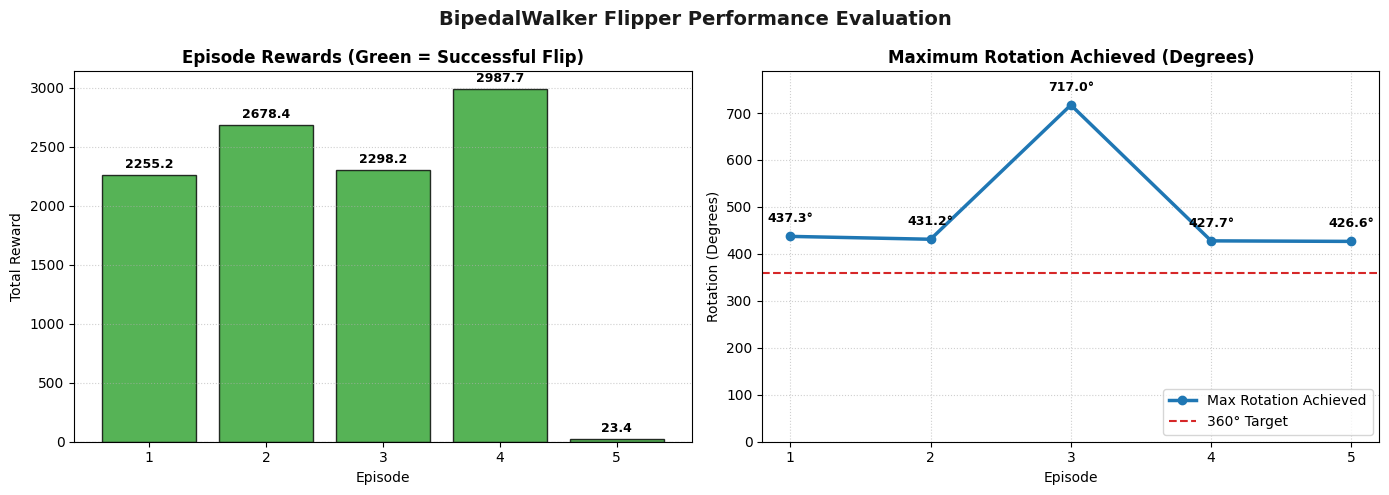

In [4]:
import time
import os
import gymnasium as gym
import torch
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import PPO

# --- ANSI Color Codes for Premium Console Styling ---
class Colors:
    HEADER = '\033[95m'
    BLUE = '\033[94m'
    CYAN = '\033[96m'
    GREEN = '\033[92m'
    WARNING = '\033[93m'
    FAIL = '\033[91m'
    ENDC = '\033[0m'
    BOLD = '\033[1m'
    UNDERLINE = '\033[4m'

# 1. Corrected model path to match what was saved at the end of Stage 2
model_path = "ppo_bipedal_stage3.zip" 
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"{Colors.BOLD}{Colors.HEADER}=================================================={Colors.ENDC}")
print(f"{Colors.BOLD}🤖 BIPEDAL WALKER FLIPPER EVALUATION RUN 🤖{Colors.ENDC}")
print(f"{Colors.BOLD}{Colors.HEADER}=================================================={Colors.ENDC}")
print(f"• Hardware Device: {Colors.BOLD}{Colors.GREEN}{device.upper()}{Colors.ENDC}")
print(f"• Evaluation Stage: {Colors.BOLD}{Colors.BLUE}Stage 2 (Stabilization and Landing){Colors.ENDC}")

# Create a single human-render environment and wrap it
import custom_bipedal
env = custom_bipedal.BipedalWalker(hardcore=False, render_mode="human")

# 2. Wrap the environment using Stage3BalanceWrapper for Stage 3 evaluation
env = Stage3BalanceWrapper(env)

if not os.path.exists(model_path):
    raise FileNotFoundError(f"Model not found: {model_path}. Train and save the model before running tests.")

print(f"• Loading weights from: {Colors.BOLD}{Colors.CYAN}{model_path}{Colors.ENDC}...")
model = PPO.load(model_path, device=device)
print(f"• Model loaded successfully! Starting evaluation...\n")

num_episodes = 5
max_seconds = 5

# Lists to store metrics for final stats and plotting
ep_rewards = []
ep_steps = []
ep_max_angles = []
ep_airtimes = []
ep_successes = []

for ep in range(1, num_episodes + 1):
    obs, info = env.reset()
    start_time = time.time()
    done = False
    total_reward = 0.0
    step_count = 0
    airtime_steps = 0
    
    # Milestone tracking for this episode
    milestones_passed = {90: False, 180: False, 270: False, 360: False}
    max_angle_deg = 0.0

    print(f"{Colors.BOLD}{Colors.BLUE}=================================================={Colors.ENDC}")
    print(f"🤸 {Colors.BOLD}TEST EPISODE {ep} / {num_episodes}{Colors.ENDC}")
    print(f"{Colors.BOLD}{Colors.BLUE}=================================================={Colors.ENDC}")
    print(f"{Colors.BOLD}[Live Event Log]{Colors.ENDC}")
    
    while not done and (time.time() - start_time) < max_seconds:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        total_reward += reward
        step_count += 1
        
        # Track airtime: index 8 and 13 are left and right leg contacts
        if obs[8] == 0.0 and obs[13] == 0.0:
            airtime_steps += 1
            
        # Track maximum rotation reached so far in degrees
        current_angle_rad = info.get("cumulative_angle", 0.0)
        current_angle_deg = abs(current_angle_rad) * (180.0 / np.pi)
        max_angle_deg = max(max_angle_deg, current_angle_deg)
        
        # Check milestones for live logging
        for milestone in [90, 180, 270, 360]:
            if not milestones_passed[milestone] and max_angle_deg >= milestone:
                milestones_passed[milestone] = True
                if milestone == 360:
                    print(f"  ↳ 🌟 {Colors.BOLD}{Colors.GREEN}[360° FULL FLIP COMPLETED!]{Colors.ENDC} at step {step_count}")
                else:
                    print(f"  ↳ 🔄 Milestone {milestone}° passed at step {step_count}")

    # Close of episode metrics
    flip_completed = info.get("flip_completed", False)
    final_angle_rad = info.get("cumulative_angle", 0.0)
    final_angle_deg = final_angle_rad * (180.0 / np.pi)
    
    airtime_pct = (airtime_steps / step_count) * 100 if step_count > 0 else 0.0
    
    # Determine the visual landing/termination outcome
    hull_angle_rad = obs[0]
    is_upright = abs(hull_angle_rad) < 0.4
    
    if flip_completed:
        if is_upright and (obs[8] == 1.0 or obs[13] == 1.0):
            outcome = f"{Colors.BOLD}{Colors.GREEN}🎉 PERFECT LANDING! (Landed upright on feet){Colors.ENDC}"
        elif is_upright:
            outcome = f"{Colors.GREEN}🟢 STABILIZING (Upright in air/landing){Colors.ENDC}"
        else:
            outcome = f"{Colors.WARNING}🟡 FLIPPED but CRASHED / OFF-BALANCE{Colors.ENDC}"
    else:
        if terminated:
            outcome = f"{Colors.FAIL}💥 CRASHED / FELL BEFORE FLIP{Colors.ENDC}"
        else:
            outcome = f"{Colors.CYAN}⏱️ TIMEOUT / INCOMPLETE FLIP{Colors.ENDC}"
            
    # Print beautiful episode summary
    print(f"\n{Colors.BOLD}[Episode Summary]{Colors.ENDC}")
    print(f"  • Outcome:           {outcome}")
    print(f"  • Total Reward:      {Colors.BOLD}{total_reward:.2f}{Colors.ENDC}")
    print(f"  • Total Steps:       {step_count} steps")
    print(f"  • Max Rotation:      {Colors.BOLD}{max_angle_deg:.1f}°{Colors.ENDC} / 360.0° "
          f"({(max_angle_deg/360.0):.1f} flips)")
    print(f"  • Airtime:           {airtime_pct:.1f}% of episode")
    print(f"  • Final Hull Angle:  {final_angle_rad:.2f} rad ({final_angle_deg:.1f}°)")
    print()

    # Append to stat lists
    ep_rewards.append(total_reward)
    ep_steps.append(step_count)
    ep_max_angles.append(max_angle_deg)
    ep_airtimes.append(airtime_pct)
    ep_successes.append(1 if flip_completed else 0)

    time.sleep(0.5)

env.close()

# --- Print Global Evaluation Summary Table ---
print(f"{Colors.BOLD}{Colors.HEADER}=================================================={Colors.ENDC}")
print(f"📊 {Colors.BOLD}GLOBAL EVALUATION METRICS SUMMARY{Colors.ENDC}")
print(f"{Colors.BOLD}{Colors.HEADER}=================================================={Colors.ENDC}")

success_rate = (sum(ep_successes) / num_episodes) * 100
avg_reward = np.mean(ep_rewards)
std_reward = np.std(ep_rewards)
max_reward_idx = np.argmax(ep_rewards)
avg_steps = np.mean(ep_steps)
avg_max_angle = np.mean(ep_max_angles)
avg_airtime = np.mean(ep_airtimes)

print(f"  • Success Rate (Full Flip): {Colors.BOLD}{Colors.GREEN if success_rate > 50 else Colors.WARNING}{success_rate:.1f}%{Colors.ENDC}")
print(f"  • Average Reward:           {Colors.BOLD}{avg_reward:.2f} ± {std_reward:.2f}{Colors.ENDC}")
print(f"  • Best Reward:              {Colors.BOLD}{Colors.GREEN}{np.max(ep_rewards):.2f}{Colors.ENDC} (Episode {max_reward_idx + 1})")
print(f"  • Average Steps:            {avg_steps:.1f} steps")
print(f"  • Avg Max Rotation:         {avg_max_angle:.1f}°")
print(f"  • Avg Airtime:              {avg_airtime:.1f}%")
print(f"{Colors.BOLD}{Colors.HEADER}=================================================={Colors.ENDC}\n")

# --- Generate Premium Jupyter Plots ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('BipedalWalker Flipper Performance Evaluation', fontsize=14, fontweight='bold', color='#1a1a1a')

# 1. Plot Rewards
colors_list = ['#2ca02c' if s == 1 else '#d62728' for s in ep_successes]
bars = ax1.bar(range(1, num_episodes + 1), ep_rewards, color=colors_list, edgecolor='black', alpha=0.8)
ax1.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax1.set_title('Episode Rewards (Green = Successful Flip)', fontsize=12, fontweight='semibold')
ax1.set_xlabel('Episode', fontsize=10)
ax1.set_ylabel('Total Reward', fontsize=10)
ax1.set_xticks(range(1, num_episodes + 1))
ax1.grid(axis='y', linestyle=':', alpha=0.6)

for bar in bars:
    height = bar.get_height()
    ax1.annotate(f'{height:.1f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3 if height >= 0 else -12),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9, fontweight='bold')

# 2. Plot Max Rotation
ax2.plot(range(1, num_episodes + 1), ep_max_angles, marker='o', linewidth=2.5, color='#1f77b4', label='Max Rotation Achieved')
ax2.axhline(360, color='#d62728', linestyle='--', linewidth=1.5, label='360° Target')
ax2.set_title('Maximum Rotation Achieved (Degrees)', fontsize=12, fontweight='semibold')
ax2.set_xlabel('Episode', fontsize=10)
ax2.set_ylabel('Rotation (Degrees)', fontsize=10)
ax2.set_xticks(range(1, num_episodes + 1))
ax2.set_ylim(0, max(400, max(ep_max_angles) * 1.1))
ax2.grid(linestyle=':', alpha=0.6)
ax2.legend(loc='lower right')

for idx, val in enumerate(ep_max_angles):
    ax2.annotate(f'{val:.1f}°',
                xy=(idx + 1, val),
                xytext=(0, 8),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()